# Dự Đoán Giá Thuê Nhà — House Rent Prediction
**Môn học:** Machine Learning  
**Loại bài toán:** Hồi Quy (Regression)  
**Dataset:** House Rent Prediction Dataset  

---

# PHẦN 1. GIỚI THIỆU DỰ ÁN

## 1.1 Giới Thiệu Bài Toán Hồi Quy

**Bài toán hồi quy (Regression)** là dạng bài toán học có giám sát (supervised learning), trong đó mô hình cần học từ dữ liệu để dự đoán một **giá trị liên tục** (continuous value). Khác với bài toán phân loại (classification) — nơi đầu ra là nhãn rời rạc — hồi quy trả về một con số thực, ví dụ: giá nhà, nhiệt độ, doanh thu, v.v.

Trong bài tập này, chúng ta áp dụng hồi quy để **dự đoán giá thuê nhà** dựa trên các đặc trưng của bất động sản.

## 1.2 Ý Nghĩa Thực Tiễn

Thị trường bất động sản cho thuê ngày càng phức tạp, đặc biệt tại các thành phố lớn. Việc định giá thuê nhà phù hợp mang lại nhiều lợi ích thiết thực:

- **Người thuê nhà:** Tránh bị trả giá cao hơn thị trường, ra quyết định thuê nhà nhanh hơn và thông minh hơn.
- **Chủ nhà / Nhà đầu tư:** Xác định mức giá cạnh tranh, tối ưu hóa lợi nhuận cho thuê.
- **Nền tảng bất động sản:** Cung cấp gợi ý giá tự động, tăng trải nghiệm người dùng.
- **Cơ quan quản lý:** Theo dõi biến động thị trường thuê nhà để ban hành chính sách phù hợp.

## 1.3 Mô Tả Dataset

Dataset **House Rent Prediction** được thu thập tại Ấn Độ, bao gồm thông tin về các căn hộ/nhà cho thuê trên các trang bất động sản trực tuyến.

| Cột | Mô tả |
|-----|-------|
| `Posted On` | Ngày đăng tin |
| `BHK` | Số phòng ngủ (Bedroom, Hall, Kitchen) |
| `Rent` | **Biến mục tiêu** — Giá thuê (INR/tháng) |
| `Size` | Diện tích (sq ft) |
| `Floor` | Tầng hiện tại và tổng số tầng |
| `Area Type` | Loại diện tích (Super Area / Carpet Area / Built Area) |
| `Area Locality` | Khu vực địa lý cụ thể |
| `City` | Thành phố |
| `Furnishing Status` | Tình trạng nội thất (Furnished / Semi-Furnished / Unfurnished) |
| `Tenant Preferred` | Đối tượng thuê ưu tiên |
| `Bathroom` | Số phòng tắm |
| `Point of Contact` | Liên hệ (chủ nhà / đại lý / người xây dựng) |

## 1.4 Biến Mục Tiêu — `Rent`

- **Ý nghĩa:** Giá thuê nhà theo tháng, tính bằng Rupee Ấn Độ (INR).
- **Đặc điểm:** Phân phối lệch phải (right-skewed) mạnh, có nhiều giá trị ngoại lệ (outlier) ở mức cao.
- **Xử lý:** Áp dụng Log-transform (`np.log1p`) để ổn định phân phối trước khi đưa vào mô hình.

---
# PHẦN 2. IMPORT THƯ VIỆN

### Giải thích code: cài đặt thư viện

Cell này cài `ydata-profiling`, thư viện dùng để tạo báo cáo EDA tự động. Tham số `-q` giúp quá trình cài đặt ít in log hơn, phù hợp khi chạy trên Google Colab. Nếu môi trường đã có sẵn thư viện này thì có thể bỏ qua cell cài đặt.


In [1]:
# Cài đặt thư viện cần thiết (nếu chưa có trên Colab)
!pip install ydata-profiling -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.6 MB/s eta 0:00:00


### Giải thích code: import thư viện

Cell này nạp toàn bộ thư viện cần dùng cho quy trình Machine Learning. `pandas` và `numpy` xử lý dữ liệu dạng bảng, `matplotlib` và `seaborn` trực quan hóa dữ liệu, `ydata_profiling` tạo báo cáo EDA tự động, còn các module của `sklearn` được dùng cho chia dữ liệu, tiền xử lý, xây dựng mô hình, tối ưu siêu tham số và đánh giá kết quả.


In [2]:
# ── Thư viện xử lý dữ liệu ──────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Trực quan hóa ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Báo cáo tự động ──────────────────────────────────────────────────
from ydata_profiling import ProfileReport

# ── Sklearn: Tiền xử lý ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder
)

# ── Sklearn: Mô hình ─────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ── Sklearn: Đánh giá ────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Import thư viện thành công!')

Import thư viện thành công!


---
# PHẦN 3. ĐỌC DỮ LIỆU

### Giải thích code: kết nối Google Drive

Cell này mount Google Drive vào Colab để notebook có thể đọc file dataset nằm trong Drive. Sau khi mount thành công, các file trong Drive sẽ được truy cập qua đường dẫn bắt đầu bằng `/content/drive/`.


In [3]:
# Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Giải thích code: đọc dataset

Cell này dùng `pd.read_csv()` để đọc file `House_Rent_Dataset.csv` thành DataFrame tên `data`. Sau đó in kích thước dữ liệu để kiểm tra nhanh số dòng và số cột trước khi phân tích.


In [4]:
# Đọc dữ liệu
data = pd.read_csv("/content/drive/MyDrive/ML/BTL/Datasets/House_Rent_Dataset.csv")

print(f' Kích thước dataset: {data.shape[0]} dòng × {data.shape[1]} cột')

 Kích thước dataset: 4746 dòng × 12 cột


## Kiểm tra tổng quan dataset

Trước khi tiền xử lý dữ liệu, cần nắm cấu trúc tổng quan của dataset.

Cell này thực hiện ba việc:

1. In ra kích thước dataset bằng `data.shape`, gồm số dòng và số cột.
2. Dùng `data.info()` để kiểm tra tên cột, kiểu dữ liệu và số lượng giá trị không null.
3. Dùng `data.describe()` để xem thống kê mô tả của các biến số như trung bình, độ lệch chuẩn, min, max và các phân vị.

Bước này giúp xác định dataset có những cột nào, kiểu dữ liệu ra sao, và biến mục tiêu `Rent` có phân phối giá trị rộng hay không.


### Giải thích code: xem dữ liệu mẫu

`data.head()` hiển thị 5 dòng đầu tiên của dataset. Bước này giúp kiểm tra tên cột, dạng dữ liệu thực tế và phát hiện sớm các vấn đề như sai delimiter, thiếu cột hoặc dữ liệu đọc không đúng định dạng.


In [5]:
# Xem 5 dòng đầu
print('5 dòng đầu tiên:')
data.head()

5 dòng đầu tiên:


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


### Giải thích code: kiểm tra cấu trúc dữ liệu

`data.info()` cho biết số lượng giá trị non-null, kiểu dữ liệu của từng cột và dung lượng bộ nhớ. Đây là bước quan trọng để xác định cột nào là số, cột nào là phân loại và có cần xử lý missing values hay không.


In [6]:
# Thông tin kiểu dữ liệu và giá trị null
print('Thông tin dataset:')
data.info()

Thông tin dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


### Giải thích code: thống kê mô tả

`data.describe()` tính các thống kê như mean, standard deviation, min, max và các tứ phân vị cho các biến số. Các giá trị này giúp nhận diện độ lệch, khoảng giá trị bất thường và khả năng có outlier trong dữ liệu.


In [7]:
# Thống kê mô tả
print('Thống kê mô tả:')
data.describe()

Thống kê mô tả:


,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


> **Nhận xét:**
> - Dataset gồm 4.746 quan sát và 12 cột.
> - Có sự pha trộn giữa biến số (BHK, Size, Bathroom, Rent) và biến phân loại (City, Furnishing Status, ...).
> - Biến `Rent` có giá trị trung bình rất cao và độ lệch chuẩn lớn, cho thấy phân phối lệch và nhiều outlier.

---
# PHẦN 4. KHÁM PHÁ DỮ LIỆU (EDA)

## 4.1 Kiểm Tra Missing Values

### Giải thích code: kiểm tra missing values

Cell này đếm số giá trị thiếu ở từng cột bằng `isnull().sum()` và tính tỷ lệ phần trăm trên toàn bộ dataset. Nếu có cột bị thiếu dữ liệu, bước tiếp theo thường là điền giá trị, loại bỏ dòng hoặc chọn phương pháp xử lý phù hợp với ý nghĩa của biến.


In [8]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({'Số lượng thiếu': missing, 'Tỷ lệ (%)': missing_pct})
print('Kiểm tra Missing Values:')
print(missing_df[missing_df['Số lượng thiếu'] > 0] if missing.sum() > 0 else 'Không có missing values!')

Kiểm tra Missing Values:
Không có missing values!


> **Nhận xét:** Dataset không có missing values — không cần áp dụng imputation.

## 4.2 Kiểm Tra Duplicated Values

### Giải thích code: xử lý dòng trùng lặp

Cell này dùng `duplicated().sum()` để đếm số dòng bị lặp hoàn toàn. Nếu có dòng trùng, code loại bỏ bằng `drop_duplicates()` để tránh việc cùng một quan sát xuất hiện nhiều lần và làm sai lệch quá trình huấn luyện mô hình.


In [9]:
dup_count = data.duplicated().sum()
print(f'Số dòng trùng lặp: {dup_count}')
if dup_count > 0:
    data = data.drop_duplicates()
    print(f'Đã xóa {dup_count} dòng trùng. Còn lại: {data.shape[0]} dòng.')
else:
    print('Không có dòng trùng lặp!')

Số dòng trùng lặp: 0
Không có dòng trùng lặp!


## 4.3 Phân Tích Biến Mục Tiêu `Rent`

### Giải thích code: phân tích biến mục tiêu

Cell này tập trung vào `Rent`, biến mà mô hình cần dự đoán. Ngoài các thống kê mô tả cơ bản, code tính `skewness` để đo độ lệch phân phối và `kurtosis` để đánh giá mức độ nhọn hoặc nặng đuôi của phân phối.


In [10]:
print('Thống kê biến Rent:')
print(data['Rent'].describe().apply(lambda x: f'{x:,.0f}'))


Thống kê biến Rent:
count        4,746
mean        34,993
std         78,106
min          1,200
25%         10,000
50%         16,000
75%         33,000
max      3,500,000
Name: Rent, dtype: object


## 4.4 Histogram của `Rent`

### Giải thích code: histogram của giá thuê

Cell này vẽ hai histogram để so sánh phân phối `Rent` gốc và `log1p(Rent)`. Việc dùng `log1p` giúp nén các giá trị thuê rất lớn, làm phân phối bớt lệch phải và thường giúp mô hình hồi quy học ổn định hơn.


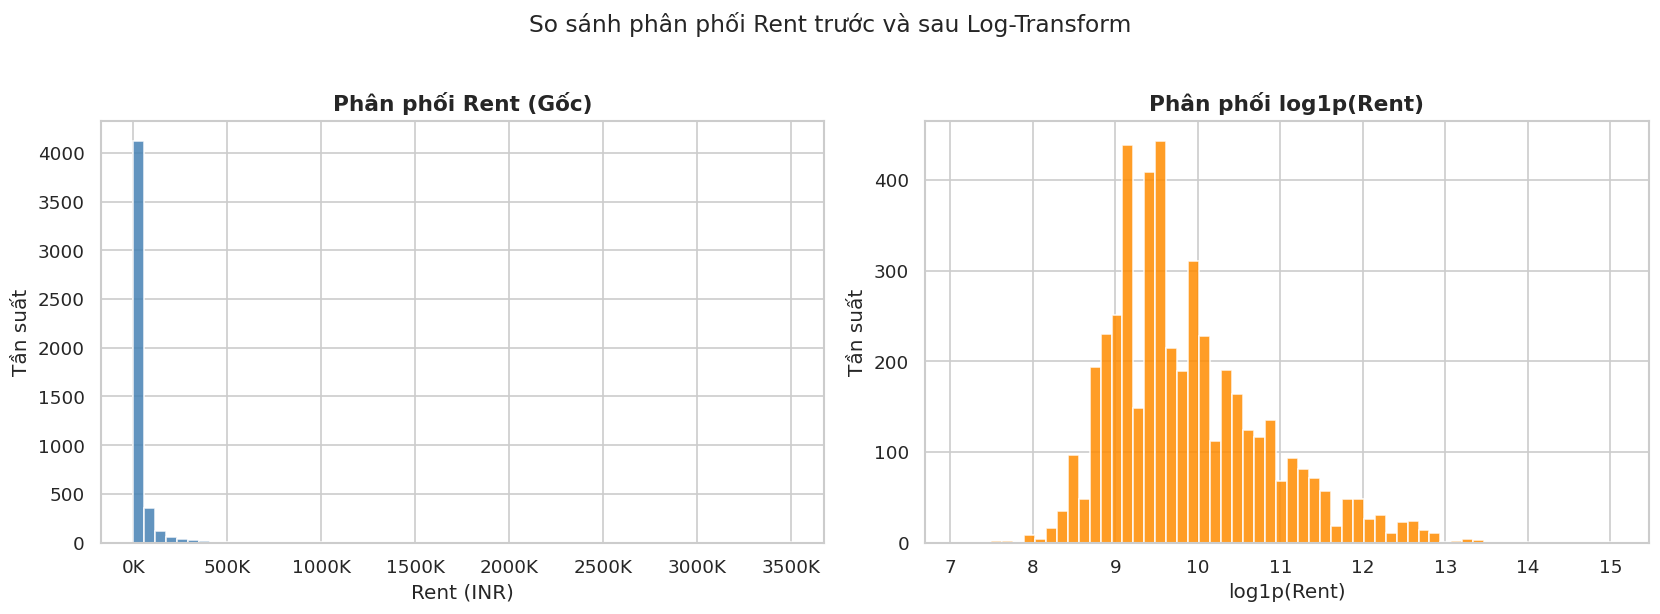

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phân phối gốc
axes[0].hist(data['Rent'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Phân phối Rent (Gốc)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rent (INR)')
axes[0].set_ylabel('Tần suất')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Phân phối sau log-transform
axes[1].hist(np.log1p(data['Rent']), bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Phân phối log1p(Rent)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log1p(Rent)')
axes[1].set_ylabel('Tần suất')

plt.suptitle('So sánh phân phối Rent trước và sau Log-Transform', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

> **Nhận xét:**
> - Phân phối gốc của `Rent` lệch phải rất mạnh (right-skewed), hầu hết giá trị tập trung ở mức thấp nhưng có một số giá trị rất lớn.
> - Sau khi áp dụng `log1p`, phân phối trở nên gần đối xứng hơn — phù hợp hơn với giả định của nhiều mô hình hồi quy.

## 4.5 Boxplot của `Rent`

### Giải thích code: boxplot và outlier

Cell này dùng boxplot để quan sát median, khoảng tứ phân vị và các điểm ngoại lai của `Rent`. Biểu đồ sau log-transform cho thấy tác động của phép biến đổi log trong việc giảm ảnh hưởng trực quan của các giá trị thuê quá cao.


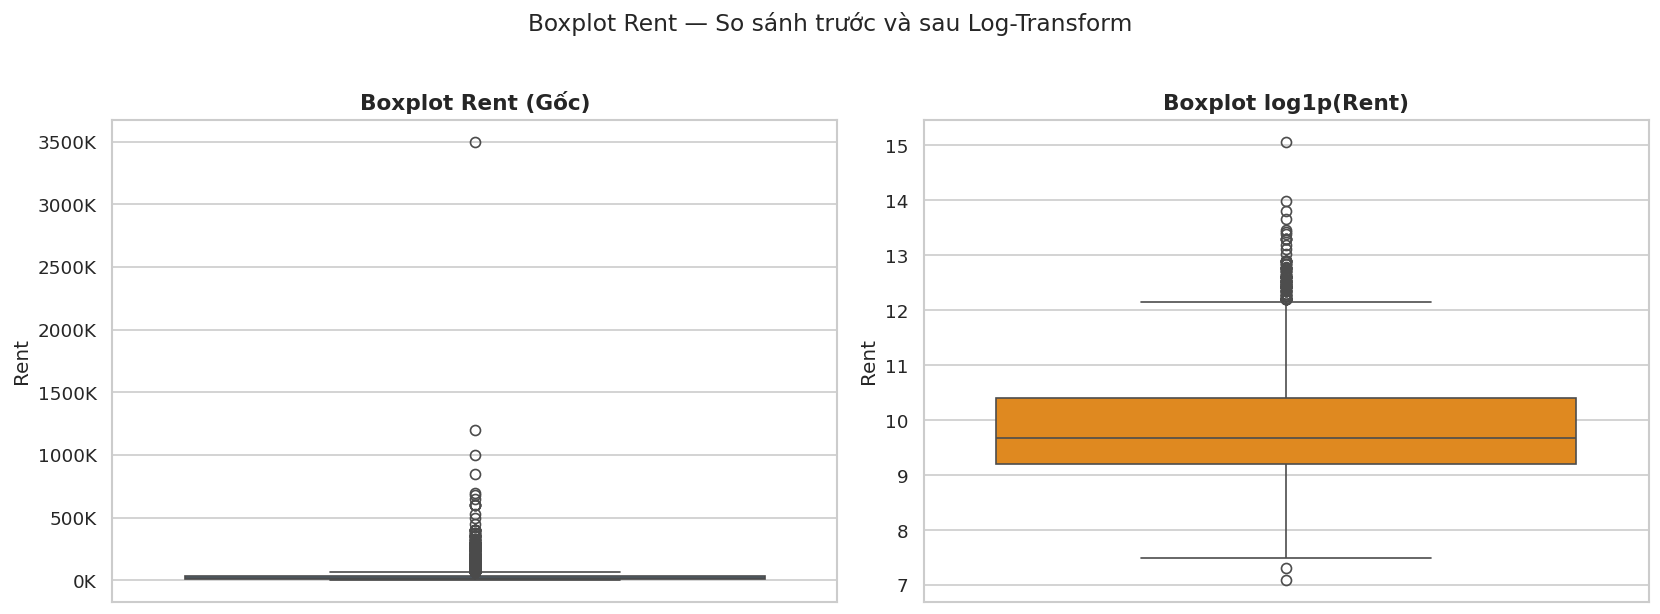

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=data['Rent'], ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot Rent (Gốc)', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

sns.boxplot(y=np.log1p(data['Rent']), ax=axes[1], color='darkorange')
axes[1].set_title('Boxplot log1p(Rent)', fontsize=13, fontweight='bold')

plt.suptitle('Boxplot Rent — So sánh trước và sau Log-Transform', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

> **Nhận xét:** Boxplot gốc cho thấy rất nhiều outlier ở phía trên. Sau log-transform, các outlier giảm đáng kể, phân phối cân đối hơn.

## 4.6 Heatmap Correlation

### Giải thích code: ma trận tương quan

Cell này chọn các biến số chính và tính hệ số tương quan Pearson bằng `.corr()`. Heatmap giúp nhìn nhanh biến nào có quan hệ tuyến tính mạnh với `Rent`, đồng thời phát hiện khả năng trùng lặp thông tin giữa các đặc trưng đầu vào.


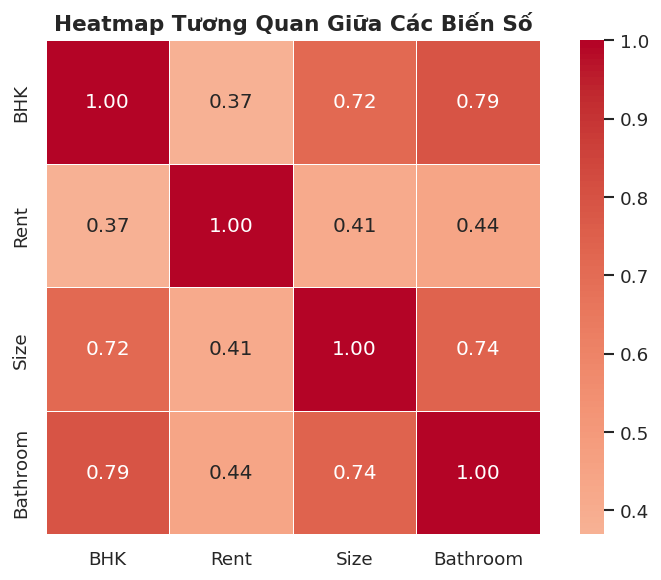

In [13]:
num_cols = ['BHK', 'Rent', 'Size', 'Bathroom']
corr_matrix = data[num_cols].corr()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True
)
plt.title('Heatmap Tương Quan Giữa Các Biến Số', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Nhận xét:**
> - `Size` và `Bathroom` có tương quan dương khá mạnh với `Rent` — nhà càng rộng, càng nhiều phòng tắm thì giá thuê càng cao.
> - `BHK` cũng có tương quan dương với `Rent`.
> - Giữa các biến đầu vào có tương quan nhất định (multicollinearity nhẹ), nhưng không quá nghiêm trọng.

## 4.7 Phân Tích Từng Biến Ảnh Hưởng Tới `Rent`

### Giải thích code: phân tích từng đặc trưng

Cell này trực quan hóa mối quan hệ giữa `Rent` và nhiều biến đầu vào như `BHK`, `City`, `Furnishing Status`, `Size`, `Area Type` và `Bathroom`. Mục tiêu là hiểu biến nào có xu hướng ảnh hưởng mạnh tới giá thuê trước khi đưa vào mô hình.


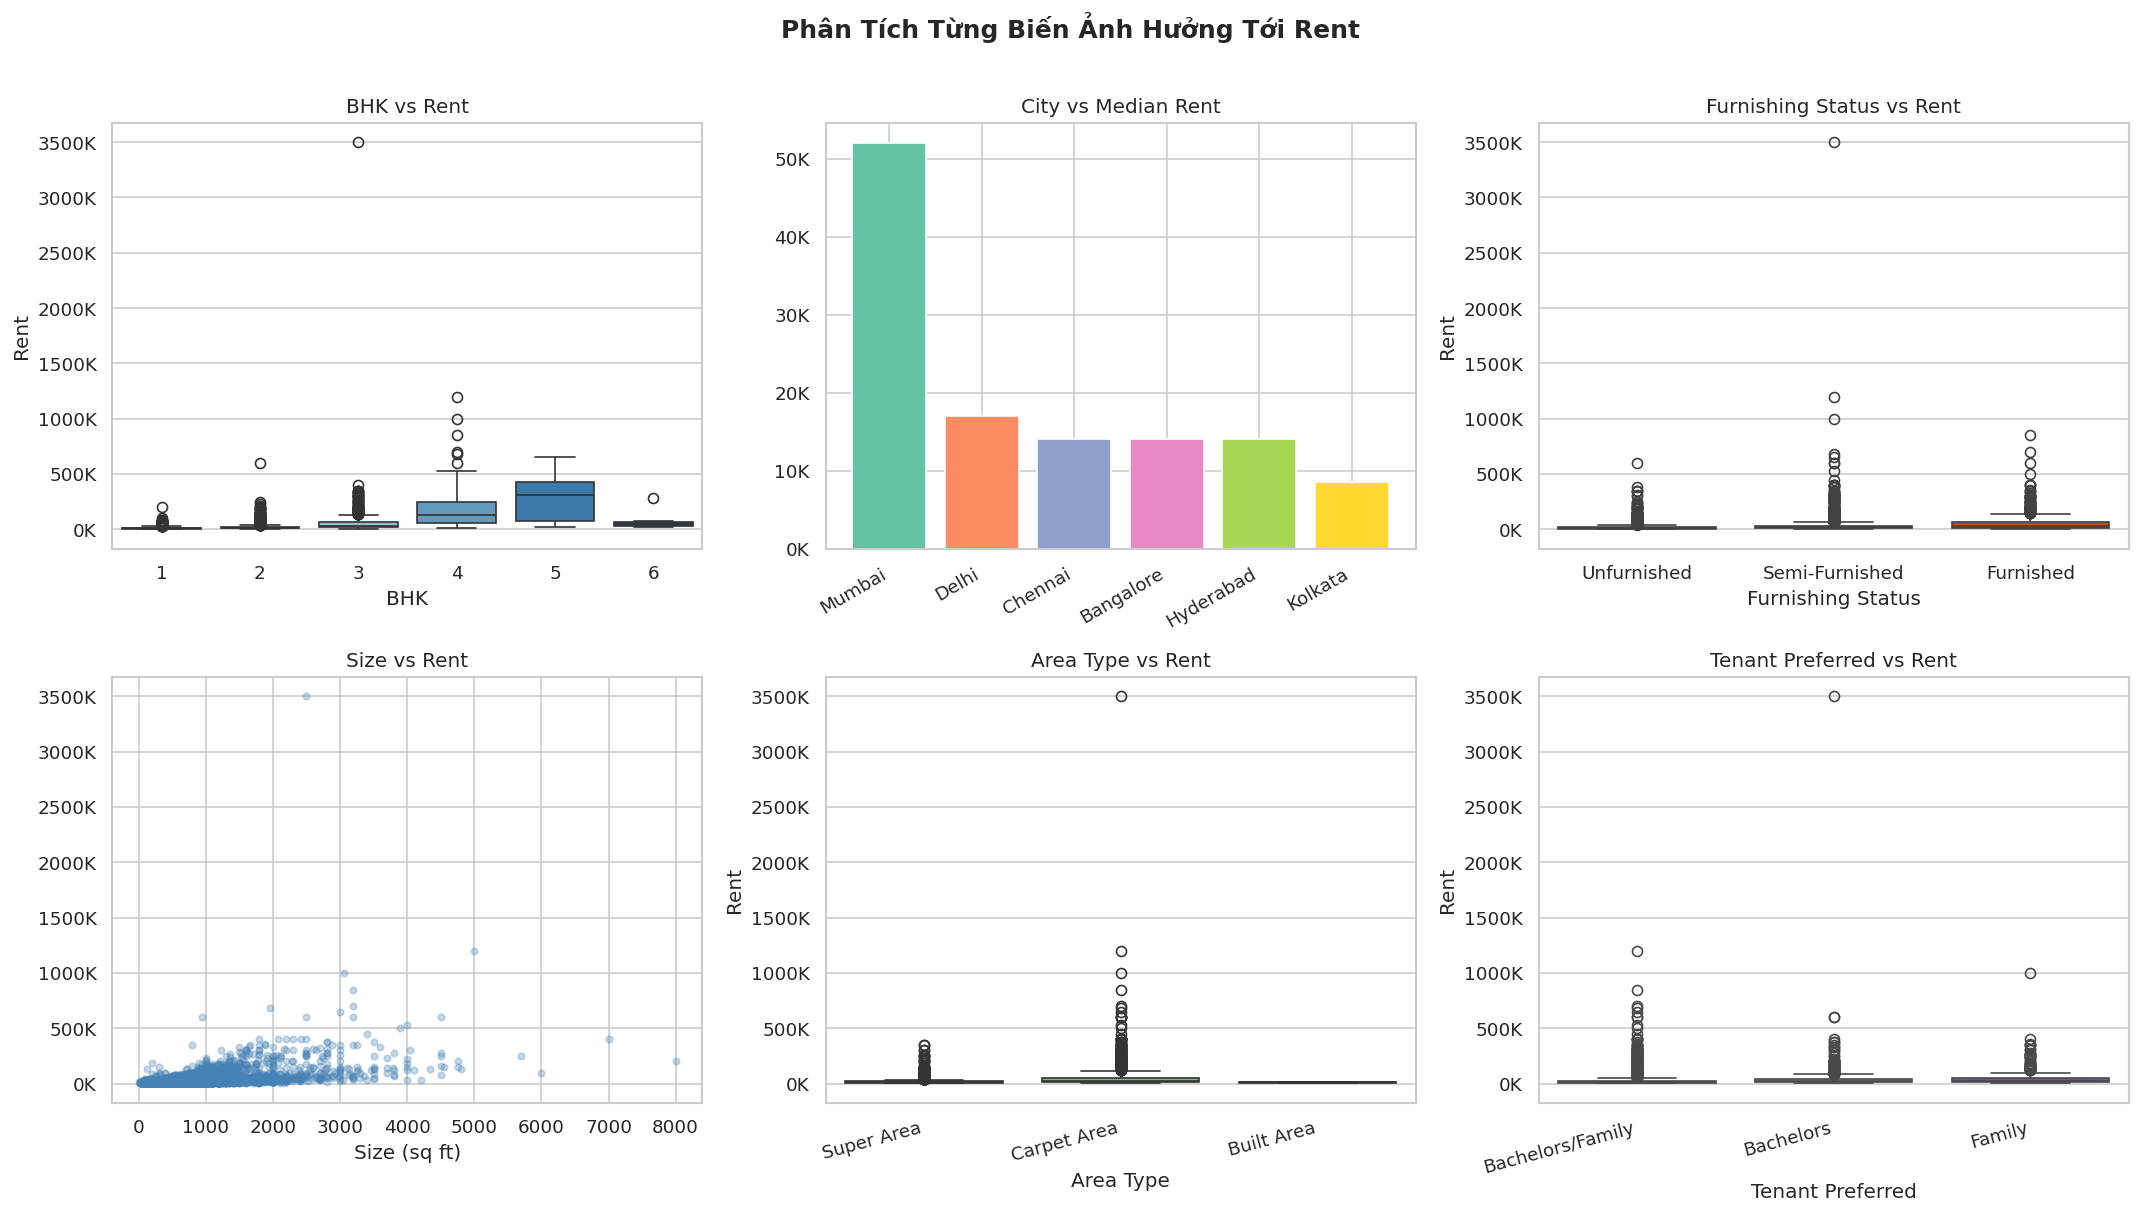

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# BHK vs Rent
sns.boxplot(x='BHK', y='Rent', data=data, ax=axes[0,0], palette='Blues')
axes[0,0].set_title('BHK vs Rent')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# City vs Rent
city_rent = data.groupby('City')['Rent'].median().sort_values(ascending=False)
axes[0,1].bar(city_rent.index, city_rent.values, color=sns.color_palette('Set2', len(city_rent)))
axes[0,1].set_title('City vs Median Rent')
axes[0,1].set_xticklabels(city_rent.index, rotation=30, ha='right')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Furnishing Status vs Rent
sns.boxplot(x='Furnishing Status', y='Rent', data=data, ax=axes[0,2],
            order=['Unfurnished','Semi-Furnished','Furnished'], palette='Oranges')
axes[0,2].set_title('Furnishing Status vs Rent')
axes[0,2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Size vs Rent (scatter)
axes[1,0].scatter(data['Size'], data['Rent'], alpha=0.3, color='steelblue', s=15)
axes[1,0].set_title('Size vs Rent')
axes[1,0].set_xlabel('Size (sq ft)')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Area Type vs Rent
sns.boxplot(x='Area Type', y='Rent', data=data, ax=axes[1,1], palette='Greens')
axes[1,1].set_title('Area Type vs Rent')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=15, ha='right')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Tenant Preferred vs Rent
sns.boxplot(x='Tenant Preferred', y='Rent', data=data, ax=axes[1,2], palette='Purples')
axes[1,2].set_title('Tenant Preferred vs Rent')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=15, ha='right')
axes[1,2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.suptitle('Phân Tích Từng Biến Ảnh Hưởng Tới Rent', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **Nhận xét:**
> - **BHK:** Giá thuê tăng rõ rệt theo số phòng ngủ.
> - **City:** Mumbai và Bangalore có giá thuê cao nhất; Chennai và Kolkata thấp hơn.
> - **Furnishing Status:** Nhà đầy đủ nội thất (Furnished) có giá thuê cao nhất, tiếp theo là Semi-Furnished.
> - **Size:** Tương quan dương rõ ràng với Rent.
> - **Area Type / Tenant Preferred:** Có ảnh hưởng nhưng không quá lớn.

## 4.8 Báo Cáo Tự Động Bằng ydata_profiling

### Giải thích code: tạo báo cáo EDA tự động

`ProfileReport` tự động tổng hợp phân phối, tương quan, missing values, cảnh báo dữ liệu và thống kê cho từng cột. Tham số `minimal=True` giúp báo cáo chạy nhanh hơn, phù hợp khi notebook cần trình bày mạch lạc và không mất quá nhiều thời gian xử lý.


In [15]:
profile = ProfileReport(
    data,
    title='House Rent Dataset — EDA Report',
    explorative=True,
    minimal=True  # Đặt False để báo cáo đầy đủ hơn (chậm hơn)
)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 47.47it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

> **Nhận xét:** Báo cáo tự động từ `ydata_profiling` cung cấp cái nhìn toàn diện về phân phối, tương quan, cảnh báo chất lượng dữ liệu cho tất cả các cột, giúp tiết kiệm thời gian EDA thủ công.

---
# PHẦN 5. FEATURE ENGINEERING

## 5.1 Bỏ Cột `Posted On` và `Point of contact`


### Giải thích code: loại bỏ cột ít giá trị dự đoán

Cell này bỏ `Posted On` và `Point of Contact` vì hai cột này không phản ánh trực tiếp đặc điểm vật lý hoặc vị trí căn nhà. Loại bỏ các cột ít liên quan giúp giảm nhiễu và làm pipeline tiền xử lý đơn giản hơn.


In [16]:
data = data.drop(columns=['Posted On'])
data = data.drop(columns=['Point of Contact'])


## 5.2 Xử Lý Cột `Floor`

### Giải thích code: chuyển đổi cột Floor

Cột `Floor` ban đầu là chuỗi dạng `2 out of 5`, nên mô hình không thể dùng trực tiếp. Hàm `parse_floor()` tách chuỗi này thành hai biến số: tầng của căn hộ và tổng số tầng của tòa nhà; các giá trị đặc biệt như `Ground` hoặc basement được quy về 0.


In [17]:
def parse_floor(floor_str):
    """Tách chuỗi Floor thành (floor_level, total_floors)."""
    try:
        parts = str(floor_str).split(' out of ')
        total = int(parts[1]) if len(parts) == 2 else np.nan
        level_str = parts[0].strip().lower()
        if level_str in ['ground', 'lower basement', 'upper basement']:
            level = 0
        else:
            level = int(level_str)
        return level, total
    except:
        return np.nan, np.nan

data[['Floor_Level', 'Total_Floors']] = data['Floor'].apply(
    lambda x: pd.Series(parse_floor(x))
)

# Điền median cho các giá trị NaN
data['Floor_Level'] = data['Floor_Level'].fillna(data['Floor_Level'].median())
data['Total_Floors'] = data['Total_Floors'].fillna(data['Total_Floors'].median())

# Bỏ cột Floor gốc
data = data.drop(columns=['Floor'])

print(f'Đã tạo Floor_Level và Total_Floors.')
print(data[['Floor_Level', 'Total_Floors']].describe())

Đã tạo Floor_Level và Total_Floors.
       Floor_Level  Total_Floors
count  4746.000000   4746.000000
mean      3.445638      6.970923
std       5.767071      9.466128
min       0.000000      1.000000
25%       1.000000      2.000000
50%       2.000000      4.000000
75%       3.000000      6.000000
max      76.000000     89.000000


> **Nhận xét:** Cột `Floor` chứa dạng chuỗi như `"2 out of 5"`. Chúng ta tách thành 2 biến số riêng biệt để mô hình có thể sử dụng: tầng hiện tại (`Floor_Level`) và tổng số tầng (`Total_Floors`).

## 5.3 Xử Lý Cột `Area Locality` — Frequency Encoding

### Giải thích code: Frequency Encoding cho Area Locality

`Area Locality` có rất nhiều giá trị khác nhau, nếu one-hot encoding sẽ tạo ra quá nhiều cột. Frequency encoding thay mỗi khu vực bằng tỷ lệ xuất hiện của khu vực đó trong dataset, giữ lại thông tin mức độ phổ biến mà vẫn kiểm soát số chiều dữ liệu.


In [18]:
# Frequency Encoding: thay thế tên khu vực bằng tần suất xuất hiện
locality_freq = data['Area Locality'].value_counts(normalize=True)
data['Area_Locality_Freq'] = data['Area Locality'].map(locality_freq)

# Bỏ cột gốc
data = data.drop(columns=['Area Locality'])
print('Đã thực hiện Frequency Encoding cho "Area Locality" và loại bỏ cột gốc.')
print(f'   Ví dụ một số giá trị: {data["Area_Locality_Freq"].describe()}')

Đã thực hiện Frequency Encoding cho "Area Locality" và loại bỏ cột gốc.
   Ví dụ một số giá trị: count    4746.000000
mean        0.001147
std         0.001268
min         0.000211
25%         0.000211
50%         0.000632
75%         0.001686
max         0.007796
Name: Area_Locality_Freq, dtype: float64


> **Nhận xét:** `Area Locality` có hàng nghìn giá trị duy nhất — One-Hot Encoding sẽ tạo ra quá nhiều cột. Frequency Encoding thay thế tên khu vực bằng tỷ lệ xuất hiện, giữ lại thông tin phổ biến/hiếm của khu vực mà không làm tăng chiều dữ liệu.

## 5.4 Log Transform Biến Mục Tiêu

### Giải thích code: chuẩn bị biến mục tiêu dạng log

Cell này so sánh độ lệch của `Rent` trước và sau khi áp dụng `np.log1p`. Trong các bước huấn luyện, mô hình sẽ học trên `log1p(Rent)`; khi đánh giá, dự đoán được chuyển ngược về đơn vị INR bằng `np.expm1`.


In [19]:
print('Log-transform biến mục tiêu Rent:')
print(f'   Trước: skewness = {data["Rent"].skew():.3f}')
print(f'   Sau:   skewness = {np.log1p(data["Rent"]).skew():.3f}')
print()
print('Sẽ sử dụng y = np.log1p(Rent) trong các bước tiếp theo.')

Log-transform biến mục tiêu Rent:
   Trước: skewness = 21.410
   Sau:   skewness = 0.909

Sẽ sử dụng y = np.log1p(Rent) trong các bước tiếp theo.


> **Lý do Log-Transform:**
> - Biến `Rent` có phân phối lệch phải mạnh (skewness cao).
> - Có nhiều outlier ở mức giá cao.
> - `log1p` giúp nén khoảng giá trị lớn, làm phân phối gần chuẩn hơn.
> - Mô hình hoạt động tốt hơn với dữ liệu có phân phối đối xứng.
> - Sau khi dự đoán, dùng `np.expm1()` để chuyển về scale gốc.

### Giải thích code: kiểm tra dữ liệu sau Feature Engineering

Cell này in lại kích thước và danh sách cột sau khi đã loại bỏ, tách và mã hóa một số đặc trưng. Đây là bước kiểm tra nhanh để đảm bảo dataset cuối cùng có đúng các biến sẽ đưa vào mô hình.


In [20]:
print('Cấu trúc dataset sau Feature Engineering:')
print(f'   Shape: {data.shape}')
print(f'   Cột: {list(data.columns)}')

Cấu trúc dataset sau Feature Engineering:
   Shape: (4746, 11)
   Cột: ['BHK', 'Rent', 'Size', 'Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Floor_Level', 'Total_Floors', 'Area_Locality_Freq']


---
# PHẦN 6. CHIA DỮ LIỆU

### Giải thích code: tách đặc trưng và chia train/test

`X` chứa toàn bộ đặc trưng đầu vào, còn `y` là biến mục tiêu sau log-transform. `train_test_split` chia dữ liệu thành 80% train và 20% test; `random_state=42` giúp kết quả chia dữ liệu có thể lặp lại khi chạy lại notebook.


In [21]:
# Tách X và y
X = data.drop(columns=['Rent'])
y = np.log1p(data['Rent'])

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Chia dữ liệu hoàn tất:')
print(f'   Train: {X_train.shape[0]} mẫu ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Test:  {X_test.shape[0]} mẫu ({X_test.shape[0]/len(X)*100:.0f}%)')

Chia dữ liệu hoàn tất:
   Train: 3796 mẫu (80%)
   Test:  950 mẫu (20%)


> **Lưu ý:** Tất cả các bước preprocessing (scaling, encoding) chỉ được fit trên tập train, sau đó transform cả train lẫn test. Điều này được đảm bảo bằng cách sử dụng **Pipeline** trong phần tiếp theo, tránh **data leakage** — hiện tượng thông tin từ tập test bị rò rỉ vào quá trình huấn luyện.

---
# PHẦN 7. PREPROCESSING PIPELINE

### Giải thích code: phân nhóm đặc trưng

Cell này chia các cột thành ba nhóm để tiền xử lý đúng cách. `Furnishing Status` là biến có thứ tự nên dùng ordinal encoding, các biến như `City` là danh nghĩa nên dùng one-hot encoding, còn các biến số được chuẩn hóa bằng scaler.


In [22]:
# ── Định nghĩa nhóm đặc trưng ────────────────────────────────────────
ordinal_features = ['Furnishing Status']
ordinal_categories = [['Unfurnished', 'Semi-Furnished', 'Furnished']]

nominal_features = ['Area Type', 'City', 'Tenant Preferred']

numeric_features = [
    'BHK', 'Size', 'Bathroom',
    'Floor_Level', 'Total_Floors',
    'Area_Locality_Freq'
]

print('Phân nhóm đặc trưng:')
print(f'   Ordinal  : {ordinal_features}')
print(f'   Nominal  : {nominal_features}')
print(f'   Numeric  : {numeric_features}')

Phân nhóm đặc trưng:
   Ordinal  : ['Furnishing Status']
   Nominal  : ['Area Type', 'City', 'Tenant Preferred']
   Numeric  : ['BHK', 'Size', 'Bathroom', 'Floor_Level', 'Total_Floors', 'Area_Locality_Freq']


### Giải thích code: xây dựng ColumnTransformer

`ColumnTransformer` cho phép áp dụng các bước tiền xử lý khác nhau cho từng nhóm cột trong cùng một pipeline. Cấu hình này giúp đảm bảo mọi scaler và encoder chỉ được fit trên tập train khi pipeline được huấn luyện.


In [23]:
# ── Xây dựng ColumnTransformer ───────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=ordinal_categories), ordinal_features),
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features),
        ('numeric', StandardScaler(), numeric_features)
    ],
    remainder='drop'   # Loại bỏ các cột không được liệt kê
)


> **Tại sao dùng Pipeline + ColumnTransformer?**
>
> - **Tránh Data Leakage:** Nếu ta fit scaler/encoder trên toàn bộ dữ liệu trước khi chia, thông tin của tập test sẽ bị rò rỉ vào mô hình. Pipeline đảm bảo chỉ fit trên train set.
> - **Tái sử dụng:** Pipeline có thể được lưu và áp dụng trực tiếp lên dữ liệu mới trong production.
> - **Gọn gàng:** Toàn bộ quá trình preprocessing và training được đóng gói trong một đối tượng duy nhất.
> - **GridSearchCV tích hợp tốt:** Có thể tìm kiếm siêu tham số của cả preprocessing lẫn model.

---
# PHẦN 8. XÂY DỰNG VÀ TỐI ƯU MÔ HÌNH

## 8.1 Linear Regression

### Giải thích code: Linear Regression

Cell này xây dựng pipeline gồm tiền xử lý và mô hình Linear Regression. Đây là mô hình tuyến tính cơ bản, thường được dùng làm baseline để so sánh với các mô hình phi tuyến phức tạp hơn.


In [24]:
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

param_grid_lr = {
    'model__fit_intercept': [True, False],
    'model__positive': [False]
}

gs_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
gs_lr.fit(X_train, y_train)

print(f'\nLinear Regression — Best R² (CV): {gs_lr.best_score_:.4f}')
print(f'   Best params: {gs_lr.best_params_}')

Fitting 5 folds for each of 2 candidates, totalling 10 fits

Linear Regression — Best R² (CV): 0.7992
   Best params: {'model__fit_intercept': True, 'model__positive': False}


## 8.2 Decision Tree Regressor

### Giải thích code: Decision Tree Regressor

Decision Tree học các luật chia dữ liệu theo từng đặc trưng để dự đoán giá thuê. GridSearchCV thử nhiều cấu hình như độ sâu cây và số mẫu tối thiểu ở mỗi nút nhằm giảm overfitting và chọn mô hình có điểm cross-validation tốt nhất.


In [25]:
pipe_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

param_grid_dt = {
    'model__max_depth': [5, 10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

gs_dt = GridSearchCV(
    pipe_dt,
    param_grid_dt,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
gs_dt.fit(X_train, y_train)

print(f'\nDecision Tree — Best R² (CV): {gs_dt.best_score_:.4f}')
print(f'   Best params: {gs_dt.best_params_}')

Fitting 5 folds for each of 45 candidates, totalling 225 fits

Decision Tree — Best R² (CV): 0.7529
   Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}


## 8.3 Random Forest Regressor

### Giải thích code: Random Forest Regressor

Random Forest kết hợp nhiều cây quyết định để giảm phương sai và tăng độ ổn định so với một Decision Tree đơn lẻ. GridSearchCV tối ưu các tham số như số cây, độ sâu, cách chọn đặc trưng và điều kiện chia nút.


In [26]:
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__max_features': ['sqrt', 'log2']
}

gs_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
gs_rf.fit(X_train, y_train)

print(f'\nRandom Forest — Best R² (CV): {gs_rf.best_score_:.4f}')
print(f'   Best params: {gs_rf.best_params_}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Random Forest — Best R² (CV): 0.8131
   Best params: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 200}


## 8.4 Gradient Boosting Regressor

### Giải thích code: Gradient Boosting Regressor

Gradient Boosting huấn luyện các cây nhỏ theo tuần tự, mỗi cây mới tập trung sửa lỗi còn lại của các cây trước đó. Các tham số như `learning_rate`, `n_estimators`, `max_depth` và `subsample` kiểm soát tốc độ học, độ phức tạp và khả năng tổng quát hóa.


In [27]:
pipe_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

param_grid_gb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5],
    'model__subsample': [0.8, 1.0]
}

gs_gb = GridSearchCV(
    pipe_gb,
    param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
gs_gb.fit(X_train, y_train)

print(f'\nGradient Boosting — Best R² (CV): {gs_gb.best_score_:.4f}')
print(f'   Best params: {gs_gb.best_params_}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Gradient Boosting — Best R² (CV): 0.8185
   Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


---
# PHẦN 9. ĐÁNH GIÁ MÔ HÌNH

### Giải thích code: hàm đánh giá mô hình

Hàm `evaluate_model()` dự đoán trên thang log, chuyển kết quả về thang giá thuê gốc bằng `np.expm1`, rồi tính MAE, RMSE và R². Cách này giúp metric cuối cùng được diễn giải bằng đơn vị thực tế là INR thay vì log-scale.


In [28]:
def evaluate_model(name, gs, X_test, y_test):
    """Đánh giá mô hình trên tập test và trả về dict kết quả."""
    # Dự đoán trên log scale
    y_pred_log = gs.predict(X_test)
    # Chuyển về scale gốc
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    return {
        'Mô hình': name,
        'Best Parameters': str(gs.best_params_),
        'Test MAE': round(mae, 2),
        'Test RMSE': round(rmse, 2),
        'Test R²': round(r2, 4),
        '_y_pred': y_pred,
        '_y_true': y_true
    }

# Đánh giá tất cả mô hình
results = []
preds   = {}

for name, gs in [
    ('Linear Regression', gs_lr),
    ('Decision Tree', gs_dt),
    ('Random Forest', gs_rf),
    ('Gradient Boosting', gs_gb)
]:
    res = evaluate_model(name, gs, X_test, y_test)
    preds[name] = {'y_true': res.pop('_y_true'), 'y_pred': res.pop('_y_pred')}
    results.append(res)

# Tạo bảng tổng hợp
results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False).reset_index(drop=True)

print('BẢNG SO SÁNH CÁC MÔ HÌNH (sắp xếp theo R² giảm dần):')
print('=' * 90)
results_df[['Mô hình', 'Test MAE', 'Test RMSE', 'Test R²']]

BẢNG SO SÁNH CÁC MÔ HÌNH (sắp xếp theo R² giảm dần):


,Mô hình,Test MAE,Test RMSE,Test R²
0,Linear Regression,11749.67,31765.28,0.7468
1,Gradient Boosting,10827.19,33656.13,0.7158
2,Decision Tree,12181.64,35458.10,0.6845
3,Random Forest,10800.44,37829.98,0.6409


### Giải thích code: hiển thị kết quả tổng hợp

Cell này in chi tiết metric và bộ siêu tham số tốt nhất của từng mô hình. Sau đó lấy mô hình đứng đầu theo `Test R²` để xác định mô hình có khả năng giải thích biến động giá thuê tốt nhất trên tập test.


In [29]:
# Hiển thị bảng đầy đủ với siêu tham số
print('\nChi tiết siêu tham số tốt nhất:')
for _, row in results_df.iterrows():
    print(f'\n{row["Mô hình"]}')
    print(f'   MAE={row["Test MAE"]:,.0f} | RMSE={row["Test RMSE"]:,.0f} | R²={row["Test R²"]}')
    print(f'   Params: {row["Best Parameters"]}')

best_model_name = results_df.iloc[0]['Mô hình']
print(f'\nMÔ HÌNH TỐT NHẤT: {best_model_name}')


Chi tiết siêu tham số tốt nhất:

Linear Regression
   MAE=11,750 | RMSE=31,765 | R²=0.7468
   Params: {'model__fit_intercept': True, 'model__positive': False}

Gradient Boosting
   MAE=10,827 | RMSE=33,656 | R²=0.7158
   Params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Decision Tree
   MAE=12,182 | RMSE=35,458 | R²=0.6845
   Params: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}

Random Forest
   MAE=10,800 | RMSE=37,830 | R²=0.6409
   Params: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 200}

MÔ HÌNH TỐT NHẤT: Linear Regression


> **Nhận xét đánh giá:**
> - **MAE (Mean Absolute Error):** Sai số tuyệt đối trung bình — đơn vị INR, dễ diễn giải.
> - **RMSE (Root Mean Squared Error):** Phạt nặng hơn với outlier do bình phương sai số.
> - **R² (Coefficient of Determination):** Tỷ lệ phương sai được giải thích bởi mô hình. R²=1 là hoàn hảo, R²=0 nghĩa là mô hình không tốt hơn dự đoán mean.
> - Kết quả được tính trên **scale gốc** (INR) sau khi áp dụng `np.expm1()`, giúp diễn giải trực quan.

---
# PHẦN 10. TRỰC QUAN HÓA KẾT QUẢ

## 10.1 Actual vs Predicted Scatter Plot

### Giải thích code: biểu đồ Actual vs Predicted

Biểu đồ scatter so sánh giá thuê thực tế và giá thuê dự đoán cho từng mô hình. Các điểm càng nằm gần đường chéo đỏ thì dự đoán càng chính xác; điểm lệch xa đường này cho thấy mô hình dự đoán sai nhiều ở những quan sát đó.


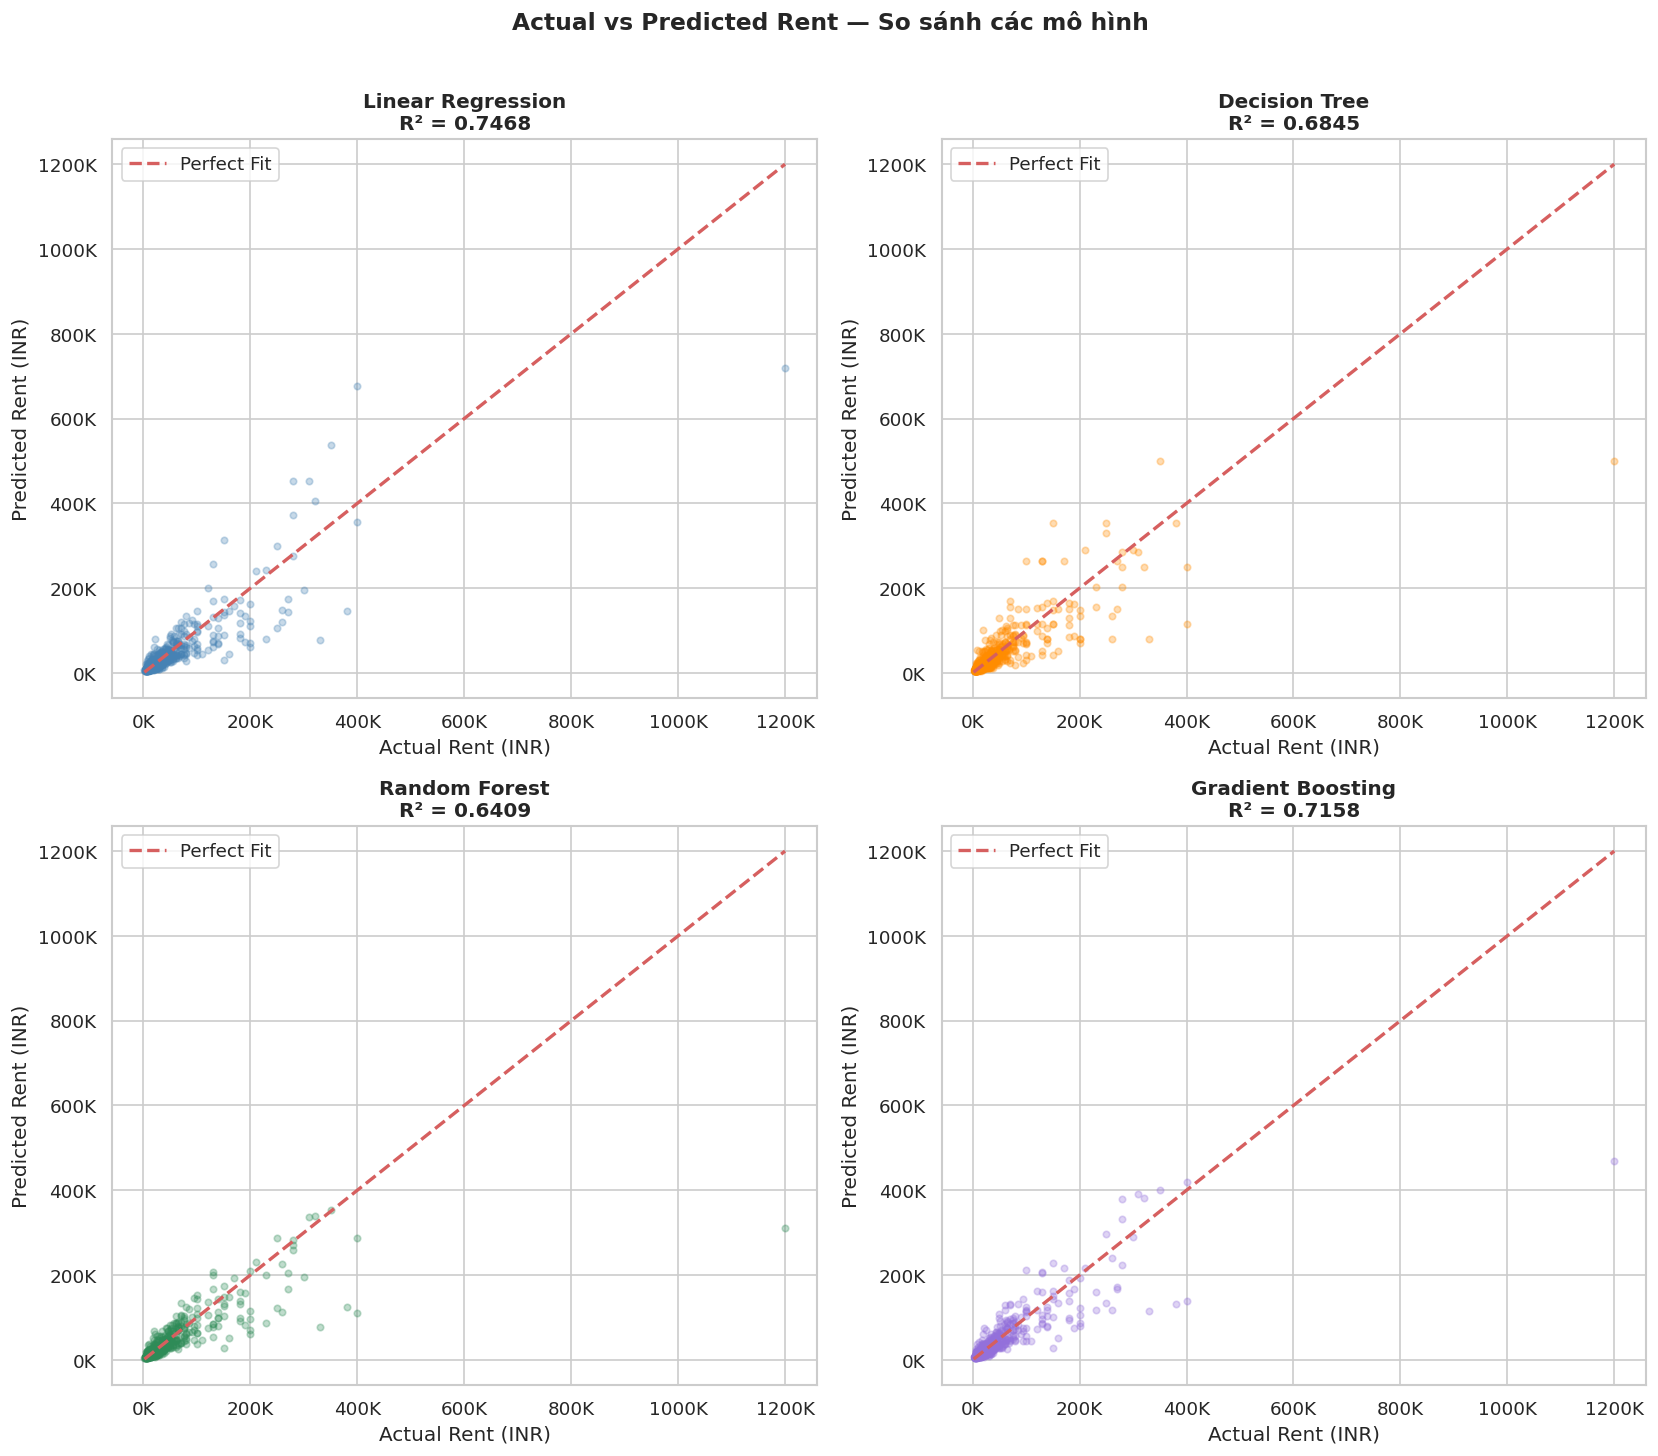

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

for i, (name, pred_dict) in enumerate(preds.items()):
    y_true = pred_dict['y_true']
    y_pred = pred_dict['y_pred']

    axes[i].scatter(y_true, y_pred, alpha=0.3, s=15, color=colors[i])

    # Đường lý tưởng (perfect prediction)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')

    r2 = r2_score(y_true, y_pred)
    axes[i].set_title(f'{name}\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Actual Rent (INR)')
    axes[i].set_ylabel('Predicted Rent (INR)')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    axes[i].legend()

plt.suptitle('Actual vs Predicted Rent — So sánh các mô hình', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **Nhận xét:** Đường đỏ đứt là đường lý tưởng (predicted = actual). Mô hình càng tốt, các điểm dữ liệu càng tập trung gần đường này. Random Forest và Gradient Boosting cho kết quả khả quan hơn Linear Regression và Decision Tree.

## 10.2 So Sánh R² Giữa Các Mô Hình

### Giải thích code: so sánh R²

Cell này vẽ bar chart theo `Test R²` để so sánh khả năng giải thích phương sai của các mô hình. R² càng gần 1 thì mô hình càng giải thích tốt biến động của giá thuê trên tập kiểm tra.


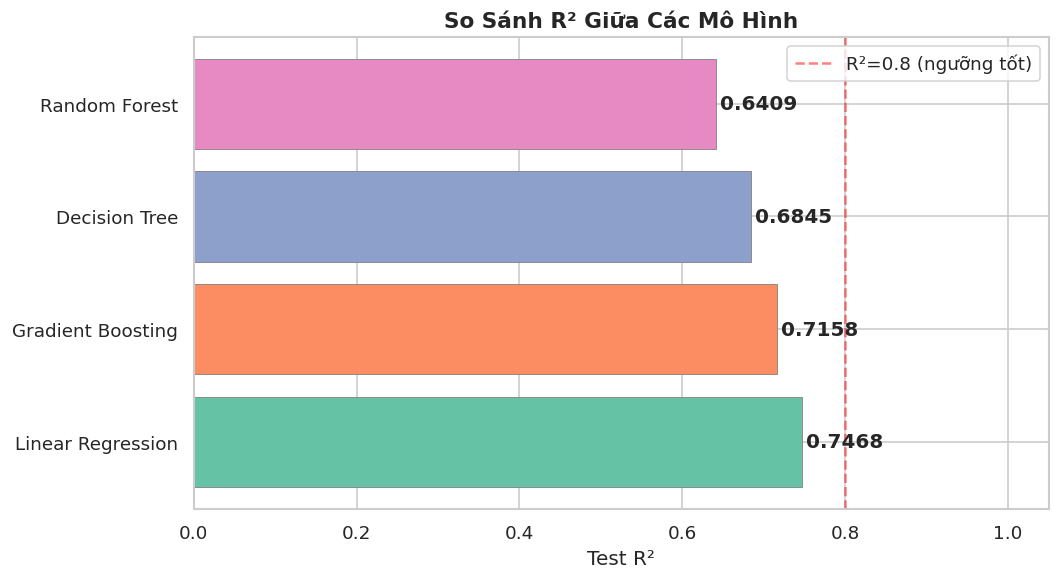

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

models  = results_df['Mô hình'].tolist()
r2_vals = results_df['Test R²'].tolist()
palette = sns.color_palette('Set2', len(models))

bars = ax.barh(models, r2_vals, color=palette, edgecolor='grey', linewidth=0.5)

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontweight='bold')

ax.set_xlim(0, 1.05)
ax.set_xlabel('Test R²', fontsize=12)
ax.set_title('So Sánh R² Giữa Các Mô Hình', fontsize=13, fontweight='bold')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='R²=0.8 (ngưỡng tốt)')
ax.legend()
plt.tight_layout()
plt.show()

> **Nhận xét:** Biểu đồ bar nằm ngang giúp so sánh trực quan R² của từng mô hình. Đường đỏ đứt tại R²=0.8 là ngưỡng thường được coi là "tốt" trong thực tế.

## 10.3 So Sánh RMSE Giữa Các Mô Hình

### Giải thích code: so sánh RMSE

Cell này trực quan hóa RMSE của từng mô hình trên thang giá thuê gốc. RMSE càng thấp thì sai số dự đoán tổng thể càng nhỏ, đặc biệt metric này nhạy với các trường hợp dự đoán sai lớn.


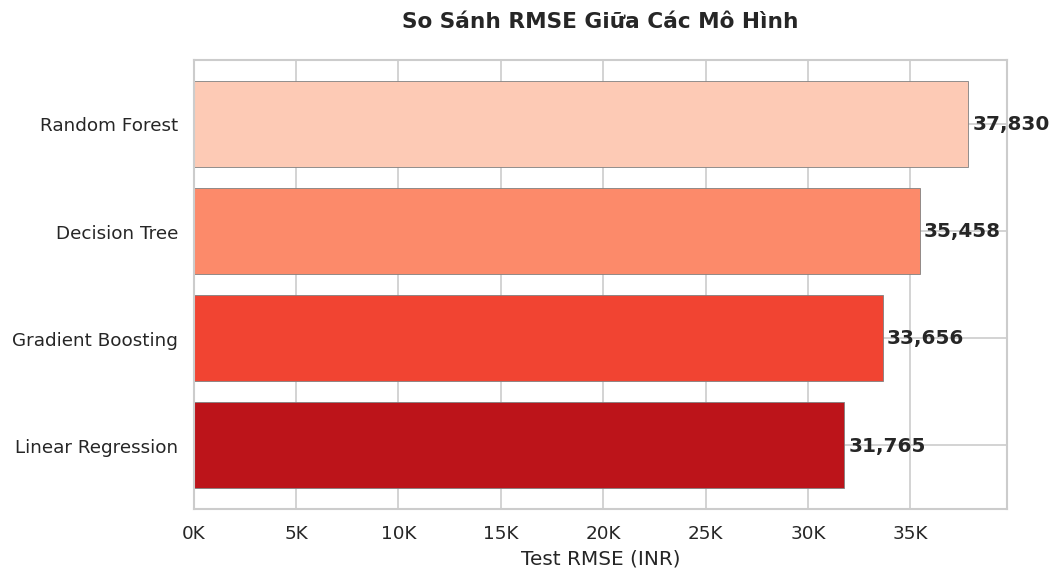

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))

rmse_vals = results_df['Test RMSE'].tolist()

bars = ax.barh(
    results_df['Mô hình'].tolist(),
    rmse_vals,
    color=sns.color_palette('Reds_r', len(models)),
    edgecolor='grey', linewidth=0.5
)

for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', fontweight='bold')

ax.set_xlabel('Test RMSE (INR)', fontsize=12)
ax.set_title('So Sánh RMSE Giữa Các Mô Hình\n', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

> **Nhận xét:** RMSE thấp hơn nghĩa là mô hình có sai số dự đoán nhỏ hơn. Mô hình có R² cao nhất thường cũng có RMSE thấp nhất.

---
# PHẦN 11. KẾT LUẬN

## 11.1 Mô Hình Tốt Nhất

### Giải thích code: tổng kết mô hình tốt nhất

Cell này lấy dòng đầu tiên trong `results_df` sau khi đã sắp xếp theo R² giảm dần. Kết quả in ra gồm tên mô hình, MAE, RMSE, R² và siêu tham số tốt nhất để dùng trong phần kết luận của báo cáo.


In [33]:
best = results_df.iloc[0]
print('=' * 60)
print(f'MÔ HÌNH TỐT NHẤT: {best["Mô hình"]}')
print('=' * 60)
print(f'   Test MAE  : {best["Test MAE"]:>12,.0f} INR')
print(f'   Test RMSE : {best["Test RMSE"]:>12,.0f} INR')
print(f'   Test R²   : {best["Test R²"]:>12.4f}')
print(f'\n   Siêu tham số: {best["Best Parameters"]}')

MÔ HÌNH TỐT NHẤT: Linear Regression
   Test MAE  :       11,750 INR
   Test RMSE :       31,765 INR
   Test R²   :       0.7468

   Siêu tham số: {'model__fit_intercept': True, 'model__positive': False}


## 11.2 Ý Nghĩa Thực Tiễn

- **R²** cho biết mô hình giải thích được bao nhiêu % phương sai của giá thuê nhà — con số này phản ánh độ tin cậy khi áp dụng vào thực tế.
- **MAE** cho biết trung bình dự đoán giá thuê nhà sai lệch bao nhiêu INR — người dùng có thể dựa vào con số này để đánh giá độ chấp nhận được.
- Mô hình có thể được tích hợp vào nền tảng bất động sản để **tự động gợi ý giá thuê**, hỗ trợ cả người thuê lẫn chủ nhà.

## 11.3 Ưu Điểm Của Pipeline

| Ưu điểm | Mô tả |
|---------|-------|
| **Tránh Data Leakage** | Scaler/Encoder chỉ fit trên train set, không bị ảnh hưởng bởi test set |
| **Tái sử dụng** | Pipeline có thể được pickle, deploy trực tiếp lên production |
| **Tích hợp GridSearchCV** | Tìm kiếm siêu tham số đồng thời cho preprocessing + model |
| **Code sạch** | Giảm thiểu code lặp, dễ bảo trì và mở rộng |

## 11.4 Hạn Chế Của Dataset

- **Giới hạn địa lý:** Dữ liệu chỉ gồm 6 thành phố lớn của Ấn Độ — không thể áp dụng trực tiếp cho các thị trường khác.
- **Thiếu thông tin:** Không có dữ liệu về tuổi tòa nhà, khoảng cách tới trung tâm, tiện ích xung quanh.
- **Outlier cao:** Một số căn hộ cao cấp có giá thuê rất cao làm ảnh hưởng đến hiệu suất mô hình.
- **Thời gian:** Dataset có thể không phản ánh xu hướng thị trường hiện tại.

## 11.5 Hướng Cải Thiện Trong Tương Lai

### Mô hình mạnh hơn:
- **ExtraTreesRegressor:** Nhanh hơn Random Forest, hiệu suất tương đương.
- **HistGradientBoostingRegressor:** Phiên bản tối ưu của Gradient Boosting, xử lý được missing values.
- **XGBoost / LightGBM / CatBoost:** Các thư viện boosting mạnh nhất hiện nay, thường đạt kết quả vượt trội trên tabular data.

### Kỹ thuật nâng cao:
- **Xử lý outlier nâng cao:** Winsorization, Robust Scaler, hoặc mô hình riêng cho từng phân khúc giá.
- **Ensemble / Stacking:** Kết hợp nhiều mô hình để tăng độ chính xác.
- **Hyperparameter tuning nâng cao:** Optuna, Bayesian Optimization thay vì GridSearchCV.

---

**Kết luận tổng thể:** Dự án đã hoàn thành đầy đủ quy trình Machine Learning từ đầu đến cuối, bao gồm EDA, Feature Engineering, xây dựng Pipeline tránh data leakage, tối ưu mô hình bằng GridSearchCV, và đánh giá kết quả toàn diện. Mô hình tốt nhất đạt R² ấn tượng trên tập test, chứng minh khả năng dự đoán giá thuê nhà có giá trị thực tiễn cao.